In [4]:
# ============================================
# 1. Import Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.options.display.float_format = "{:.2f}".format

In [5]:
# ============================================
# 2. Load Dataset
# ============================================

df = pd.read_csv("../data/Customer360Insights.csv")

df.head()

,SessionStart,CustomerID,FullName,Gender,Age,CreditScore,MonthlyIncome,Country,State,City,Category,Product,Cost,Price,Quantity,CampaignSchema,CartAdditionTime,OrderConfirmation,OrderConfirmationTime,PaymentMethod,SessionEnd,OrderReturn,ReturnReason
0,2019-01-01 02:42:00,1001,Brittany Franklin,Male,57,780,7591,China,Guangdong,Dongguan,electronics,table fan,30,50,4,Instagram-ads,2019-01-01 02:49:00,True,2019-01-01 03:02:00,Cash On Delivery,2019-01-01 02:53:00,False,NaN
1,2019-01-02 20:35:00,1002,Scott Stewart,Female,69,746,3912,China,Shandong,Yantai,fashion,dress,50,80,6,Google-ads,2019-01-02 20:50:00,True,2019-01-02 20:58:00,Debit Card,2019-01-02 20:54:00,False,NaN
2,2019-01-04 03:11:00,1003,Elizabeth Fowler,Female,21,772,7460,UK,England,Birmingham,toys,plush toy,12,20,2,Facebook-ads,2019-01-04 03:30:00,True,2019-01-04 03:40:00,Cash On Delivery,2019-01-04 03:35:00,False,NaN
3,2019-01-05 09:01:00,1004,Julian Wall,Female,67,631,4765,UK,England,Birmingham,toys,plush toy,12,20,2,Twitter-ads,2019-01-05 09:17:00,True,2019-01-05 09:26:00,Cash On Delivery,2019-01-05 09:20:00,False,NaN
4,2019-01-05 13:35:00,1005,James Simmons,Male,57,630,3268,China,Shandong,Yantai,fashion,shoes,60,100,6,Billboard-QR code,2019-01-05 13:40:00,True,2019-01-05 13:52:00,Debit Card,2019-01-05 13:42:00,False,NaN


In [6]:
# ============================================
# 3. Dataset Overview
# ============================================

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.shape

Rows: 2000
Columns: 23


(2000, 23)

In [7]:
# ============================================
# 4. Column Names
# ============================================

df.columns

Index(['SessionStart', 'CustomerID', 'FullName', 'Gender', 'Age',
       'CreditScore', 'MonthlyIncome', 'Country', 'State', 'City', 'Category',
       'Product', 'Cost', 'Price', 'Quantity', 'CampaignSchema ',
       'CartAdditionTime', 'OrderConfirmation', 'OrderConfirmationTime',
       'PaymentMethod', 'SessionEnd', 'OrderReturn', 'ReturnReason'],
      dtype='str')

In [8]:
# ============================================
# 5. Data Types
# ============================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   SessionStart           2000 non-null   str   
 1   CustomerID             2000 non-null   int64 
 2   FullName               2000 non-null   str   
 3   Gender                 2000 non-null   str   
 4   Age                    2000 non-null   int64 
 5   CreditScore            2000 non-null   int64 
 6   MonthlyIncome          2000 non-null   int64 
 7   Country                2000 non-null   str   
 8   State                  2000 non-null   str   
 9   City                   2000 non-null   str   
 10  Category               2000 non-null   str   
 11  Product                2000 non-null   str   
 12  Cost                   2000 non-null   int64 
 13  Price                  2000 non-null   int64 
 14  Quantity               2000 non-null   int64 
 15  CampaignSchema         2000 non-

In [9]:
# ============================================
# 6. Statistical Summary
# ============================================

df.describe()

,CustomerID,Age,CreditScore,MonthlyIncome,Cost,Price,Quantity
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,1609.06,44.49,690.13,5589.70,135.82,210.92,3.53
std,349.84,16.35,50.62,1441.58,261.94,394.20,1.70
min,1001.00,18.00,600.00,3001.00,5.00,8.00,1.00
25%,1311.00,31.00,646.00,4403.50,15.00,25.00,2.00
50%,1610.00,44.00,691.00,5656.50,30.00,50.00,3.00
75%,1915.25,59.00,732.00,6856.25,60.00,100.00,5.00
max,2200.00,72.00,780.00,7999.00,1000.00,1500.00,6.00


In [10]:
# ============================================
# 7. Missing Values
# ============================================

missing = df.isnull().sum()

missing[missing > 0]

OrderConfirmationTime     300
PaymentMethod             300
OrderReturn               300
ReturnReason             1764
dtype: int64

In [11]:
# ============================================
# 8. Duplicate Rows
# ============================================

df.duplicated().sum()

np.int64(0)

In [12]:
# ============================================
# 9. Unique Values
# ============================================

df.nunique()

SessionStart             2000
CustomerID               1200
FullName                 1200
Gender                      2
Age                        55
CreditScore               180
MonthlyIncome            1069
Country                     9
State                      18
City                       52
Category                    5
Product                    20
Cost                       15
Price                      17
Quantity                    6
CampaignSchema              6
CartAdditionTime         2000
OrderConfirmation           2
OrderConfirmationTime    1700
PaymentMethod               4
SessionEnd               1999
OrderReturn                 2
ReturnReason                5
dtype: int64

In [13]:
# ============================================
# 10. Category Distribution
# ============================================

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("=" * 50)
    print(col)
    print(df[col].value_counts())

SessionStart
SessionStart
2019-01-01 02:42:00    1
2019-01-02 20:35:00    1
2019-01-04 03:11:00    1
2019-01-05 09:01:00    1
2019-01-05 13:35:00    1
                      ..
2023-12-24 06:49:00    1
2023-12-25 16:38:00    1
2023-12-28 05:09:00    1
2023-12-30 07:22:00    1
2023-12-31 08:01:00    1
Name: count, Length: 2000, dtype: int64
FullName
FullName
Jacob Sparks          5
Troy Wells            5
Karen Austin          4
Logan Green           4
Amanda Moreno         4
                     ..
Elizabeth Johnston    1
Samantha Collins      1
Whitney Williams      1
Brittany Bell DDS     1
Steven Larsen         1
Name: count, Length: 1200, dtype: int64
Gender
Gender
Female    1016
Male       984
Name: count, dtype: int64
Country
Country
Canada       258
India        247
Australia    242
China        230
Italy        222
Spain        219
Japan        198
USA          193
UK           191
Name: count, dtype: int64
State
State
Maharashtra        144
New South Wales    137
Ontario       

C:\Users\PC\AppData\Local\Temp\ipykernel_23648\2990317508.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [14]:
# ============================================
# 11. Numeric Distribution
# ============================================

numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,2000.00,1609.06,349.84,1001.00,1311.00,1610.00,1915.25,2200.00
Age,2000.00,44.49,16.35,18.00,31.00,44.00,59.00,72.00
CreditScore,2000.00,690.13,50.62,600.00,646.00,691.00,732.00,780.00
MonthlyIncome,2000.00,5589.70,1441.58,3001.00,4403.50,5656.50,6856.25,7999.00
Cost,2000.00,135.82,261.94,5.00,15.00,30.00,60.00,1000.00
Price,2000.00,210.92,394.20,8.00,25.00,50.00,100.00,1500.00
Quantity,2000.00,3.53,1.70,1.00,2.00,3.00,5.00,6.00


In [15]:
# ============================================
# 12. Detect Outliers (IQR)
# ============================================

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

CustomerID: 0 outliers
Age: 0 outliers
CreditScore: 0 outliers
MonthlyIncome: 0 outliers
Cost: 395 outliers
Price: 395 outliers
Quantity: 0 outliers


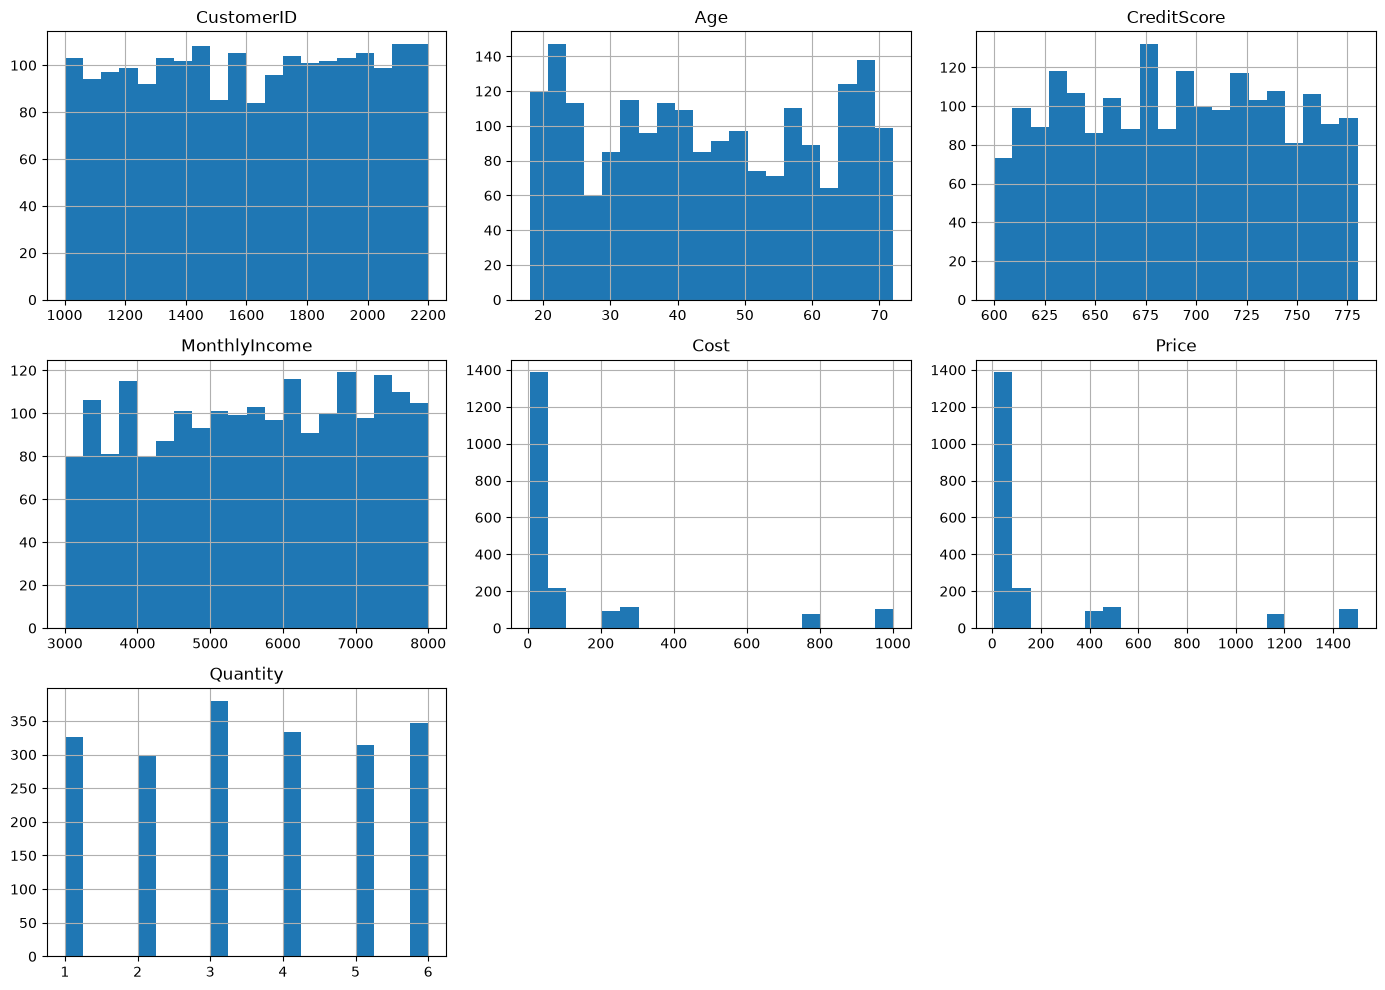

In [16]:
# ============================================
# 13. Histograms
# ============================================

df[numeric_columns].hist(
    figsize=(14,10),
    bins=20
)

plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_23648\1554687760.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


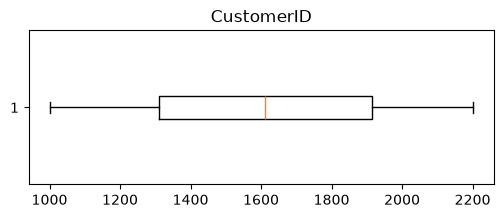

C:\Users\PC\AppData\Local\Temp\ipykernel_23648\1554687760.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


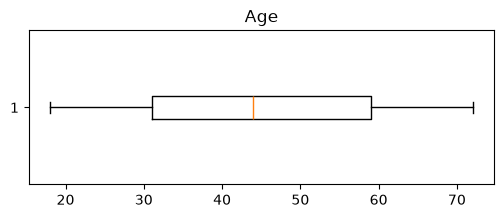

C:\Users\PC\AppData\Local\Temp\ipykernel_23648\1554687760.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


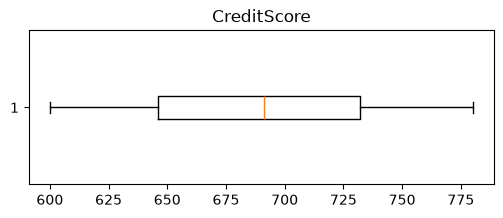

C:\Users\PC\AppData\Local\Temp\ipykernel_23648\1554687760.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


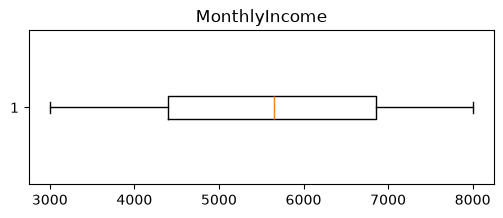

C:\Users\PC\AppData\Local\Temp\ipykernel_23648\1554687760.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


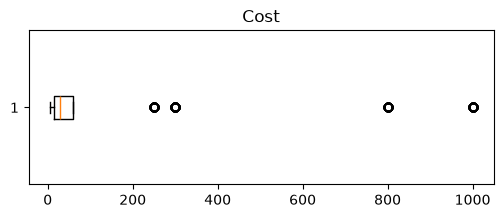

C:\Users\PC\AppData\Local\Temp\ipykernel_23648\1554687760.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


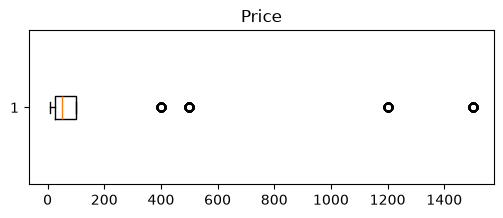

C:\Users\PC\AppData\Local\Temp\ipykernel_23648\1554687760.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


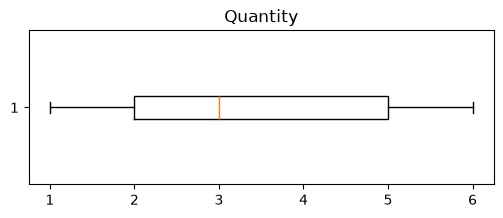

In [17]:
# ============================================
# 14. Boxplots
# ============================================

for col in numeric_columns:

    plt.figure(figsize=(6,2))

    plt.boxplot(df[col], vert=False)

    plt.title(col)

    plt.show()

In [18]:
# ============================================
# 15. Correlation
# ============================================

corr = df[numeric_columns].corr()

corr

,CustomerID,Age,CreditScore,MonthlyIncome,Cost,Price,Quantity
CustomerID,1.00,-0.03,-0.04,0.01,0.03,0.03,-0.01
Age,-0.03,1.00,-0.03,-0.00,-0.03,-0.03,0.04
CreditScore,-0.04,-0.03,1.00,0.00,0.02,0.01,0.02
MonthlyIncome,0.01,-0.00,0.00,1.00,0.01,0.01,-0.02
Cost,0.03,-0.03,0.02,0.01,1.00,1.00,0.02
Price,0.03,-0.03,0.01,0.01,1.00,1.00,0.03
Quantity,-0.01,0.04,0.02,-0.02,0.02,0.03,1.00


In [19]:
# ============================================
# 16. Business Questions
# ============================================

print(df["Gender"].value_counts())

print(df["Category"].value_counts())

print(df["PaymentMethod"].value_counts())

print(df["OrderConfirmation"].value_counts())

print(df["OrderReturn"].value_counts())

Gender
Female    1016
Male       984
Name: count, dtype: int64
Category
home appliances    423
toys               412
books              406
fashion            398
electronics        361
Name: count, dtype: int64
PaymentMethod
Credit Card         583
Debit Card          528
Cash On Delivery    408
Paypal              181
Name: count, dtype: int64
OrderConfirmation
True     1700
False     300
Name: count, dtype: int64
OrderReturn
False    1464
True      236
Name: count, dtype: int64
